**PRÁCTICA 3 - SERIES DE FOURIER, MAGNITUD Y FASE**

Integrantes: 

- Valentina Morales
- Paula García

a,b) Construya una señal cuadrada y triangular periódica, definiendo su frecuencia fundamental, amplitud y
número de muestras

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import signal as sig

In [3]:
f0 = 5 #Frecuencia fundamental en Hz
T0 = 1 / f0 #Periodo fundamental en segundos
A = 1 #Amplitud            
N = 500 #Número de muestras dentro de un periodo     
Fs = N* f0 #Frecuencia de muestreo

t = np.linspace(0, T0, N, endpoint=False)  

# a) Señal cuadrada periódica
x_sq = A * sig.square(2 * np.pi * f0 * t)

# b) Señal triangular periódica (width=0.5 -> triangular simétrica)
x_tri = A * sig.sawtooth(2 * np.pi * f0 * t, width=0.5)

print(f"f0 = {f0} Hz, T0 = {T0*1000:.1f} ms, A = {A}, N = {N} muestras/periodo", f"Fs = {Fs}")

f0 = 5 Hz, T0 = 200.0 ms, A = 1, N = 500 muestras/periodo Fs = 2500


c) Grafique ambas señales en el dominio del tiempo.

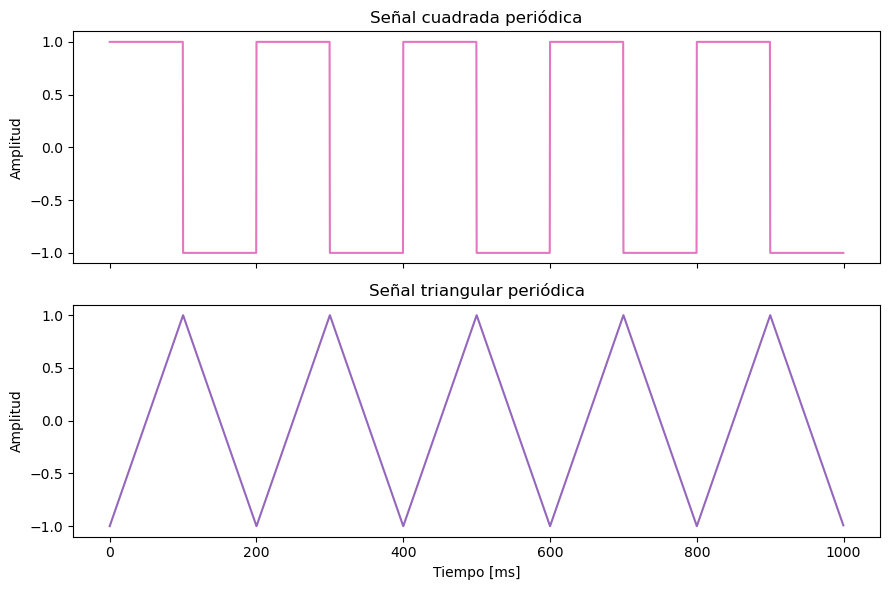

In [4]:
n_periodos = 5
t_rep = np.concatenate([t + k * T0 for k in range(n_periodos)])
x_sq_rep = np.tile(x_sq, n_periodos)
x_tri_rep = np.tile(x_tri, n_periodos)

fig, axs = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axs[0].plot(t_rep * 1000, x_sq_rep, color='tab:pink')
axs[0].set_title('Señal cuadrada periódica')
axs[0].set_ylabel('Amplitud')

axs[1].plot(t_rep * 1000, x_tri_rep, color='tab:purple')
axs[1].set_title('Señal triangular periódica')
axs[1].set_xlabel('Tiempo [ms]')
axs[1].set_ylabel('Amplitud')

plt.tight_layout()
plt.show()

d) Cree una función que reciba una señal periódica, y devuelva sus coeficientes de la serie de Fourier
(forma exponencial), calculados mediante NumPy.

In [5]:
def coeficientes_fourier(x):
    """ Calcula los coeficientes de Fourier de una señal periódica x[n] utilizando 
    la Transformada Rápida de Fourier (FFT)."""
    x = np.asarray(x)
    N = len(x)
    c_k = np.fft.fftshift(np.fft.fft(x) / N)
    k = np.fft.fftshift(np.fft.fftfreq(N, d=1/N)).astype(int)
    return k, c_k

Referencia y documentación: https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html

e) Aplique la función anterior a la señal cuadrada y a la señal triangular, y obtenga sus respectivos
coeficientes

In [6]:
k_sq, c_sq = coeficientes_fourier(x_sq)
k_tri, c_tri = coeficientes_fourier(x_tri)

print("Primeros coeficientes (cuadrada):")
for kk, cc in zip(k_sq[N//2:N//2+6], c_sq[N//2:N//2+6]):
    print(f"  c[{kk}] = {cc:.4f}  |c[{kk}]| = {abs(cc):.4f}")

print("\nPrimeros coeficientes (triangular):")
for kk, cc in zip(k_tri[N//2:N//2+6], c_tri[N//2:N//2+6]):
    print(f"  c[{kk}] = {cc:.4f}  |c[{kk}]| = {abs(cc):.4f}")

Primeros coeficientes (cuadrada):
  c[0] = 0.0000+0.0000j  |c[0]| = 0.0000
  c[1] = 0.0040-0.6366j  |c[1]| = 0.6366
  c[2] = 0.0000+0.0000j  |c[2]| = 0.0000
  c[3] = 0.0040-0.2122j  |c[3]| = 0.2122
  c[4] = 0.0000+0.0000j  |c[4]| = 0.0000
  c[5] = 0.0040-0.1273j  |c[5]| = 0.1273

Primeros coeficientes (triangular):
  c[0] = -0.0000+0.0000j  |c[0]| = 0.0000
  c[1] = -0.4053-0.0000j  |c[1]| = 0.4053
  c[2] = 0.0000+0.0000j  |c[2]| = 0.0000
  c[3] = -0.0450-0.0000j  |c[3]| = 0.0450
  c[4] = 0.0000+0.0000j  |c[4]| = 0.0000
  c[5] = -0.0162-0.0000j  |c[5]| = 0.0162


f) Cree una función que reciba un conjunto de coeficientes de Fourier y grafique el espectro de
magnitud y el espectro de fase correspondientes

In [7]:
def graficar_espectros(k, c_k, titulo="", k_max=15, umbral=1e-6):
    magnitud = np.abs(c_k)
    fase = np.angle(c_k)

    en_rango = np.abs(k) <= k_max
    significativo = magnitud > umbral * magnitud.max()

    fig, axs = plt.subplots(2, 1, sharex=True, figsize=(9, 6))

    axs[0].stem(k[en_rango], magnitud[en_rango])
    axs[0].set_title(f"Espectro de magnitud {titulo}")
    axs[0].set_ylabel("|c_k|")
    axs[0].grid(True)

    sel = en_rango & significativo
    axs[1].stem(k[sel], fase[sel])
    axs[1].set_title(f"Espectro de fase {titulo}")
    axs[1].set_xlabel("Armónico k")
    axs[1].set_ylabel("Fase (rad)")
    axs[1].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    axs[1].set_yticklabels(["-π", "-π/2", "0", "π/2", "π"])
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

g) Grafique los espectros de magnitud y fase de la señal cuadrada y de la señal triangular.

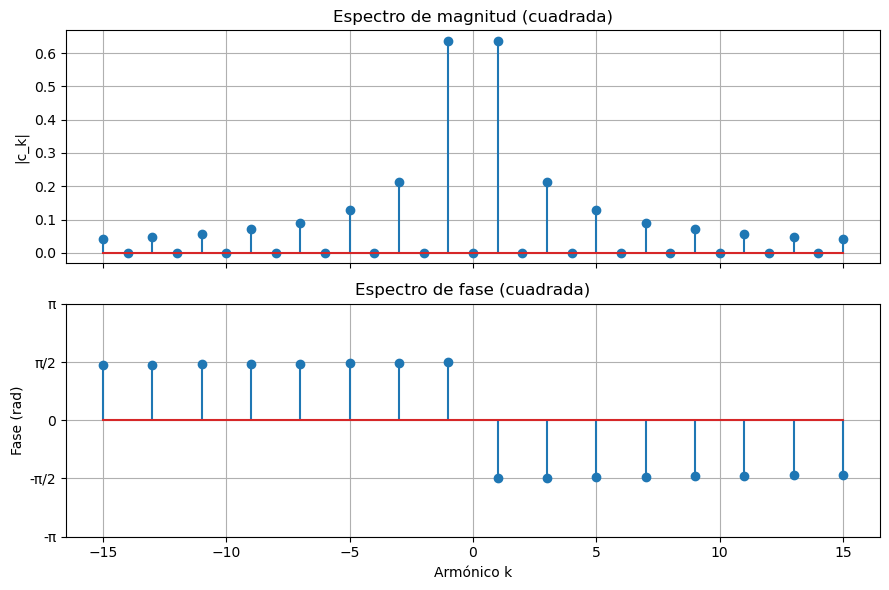

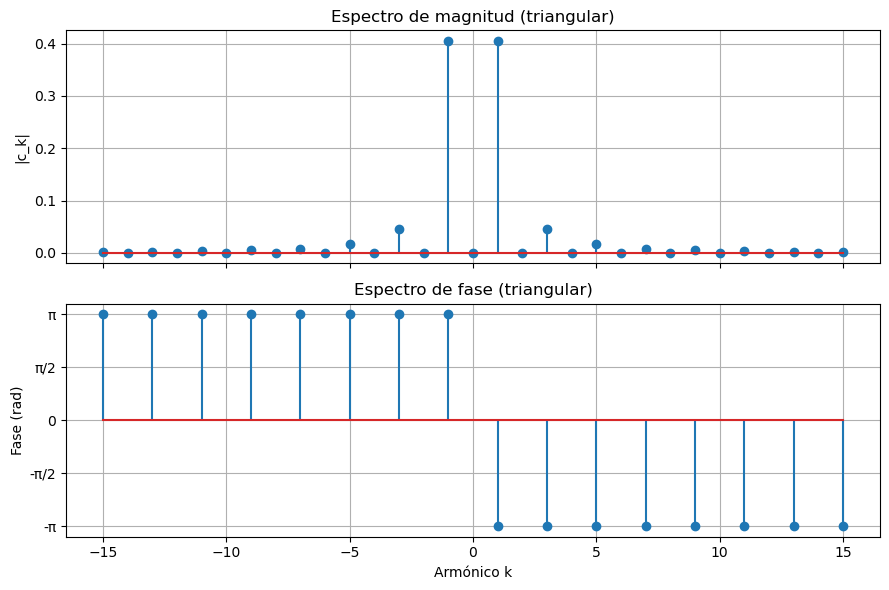

In [8]:
graficar_espectros(k_sq, c_sq, titulo="(cuadrada)")
graficar_espectros(k_tri, c_tri, titulo="(triangular)")

h) Cree una función que reconstruya una señal a partir de una suma de senos (armónicos), recibiendo
como parámetros los coeficientes de Fourier y el número de armónicos a utilizar.


In [9]:
def reconstruir_senal(k, c_k, K):
    N = len(c_k)
    n = np.arange(N)
    x_rec = np.full(N, c_k[k == 0][0].real)
    for kk in range(1, K + 1):
        ck = c_k[k == kk][0]
        x_rec += 2 * np.abs(ck) * np.cos(2*np.pi*kk*n/N + np.angle(ck))
    return x_rec

i) Reconstruya la señal cuadrada y la señal triangular utilizando N = 1, 3, 5, 20 y 50 armónicos, y
grafique cada reconstrucción junto con la señal original.


cuadrada | K =  1 | máximo de la reconstrucción = 1.2732
cuadrada | K =  3 | máximo de la reconstrucción = 1.2004
cuadrada | K =  5 | máximo de la reconstrucción = 1.1884
cuadrada | K = 20 | máximo de la reconstrucción = 1.1803
cuadrada | K = 50 | máximo de la reconstrucción = 1.1724


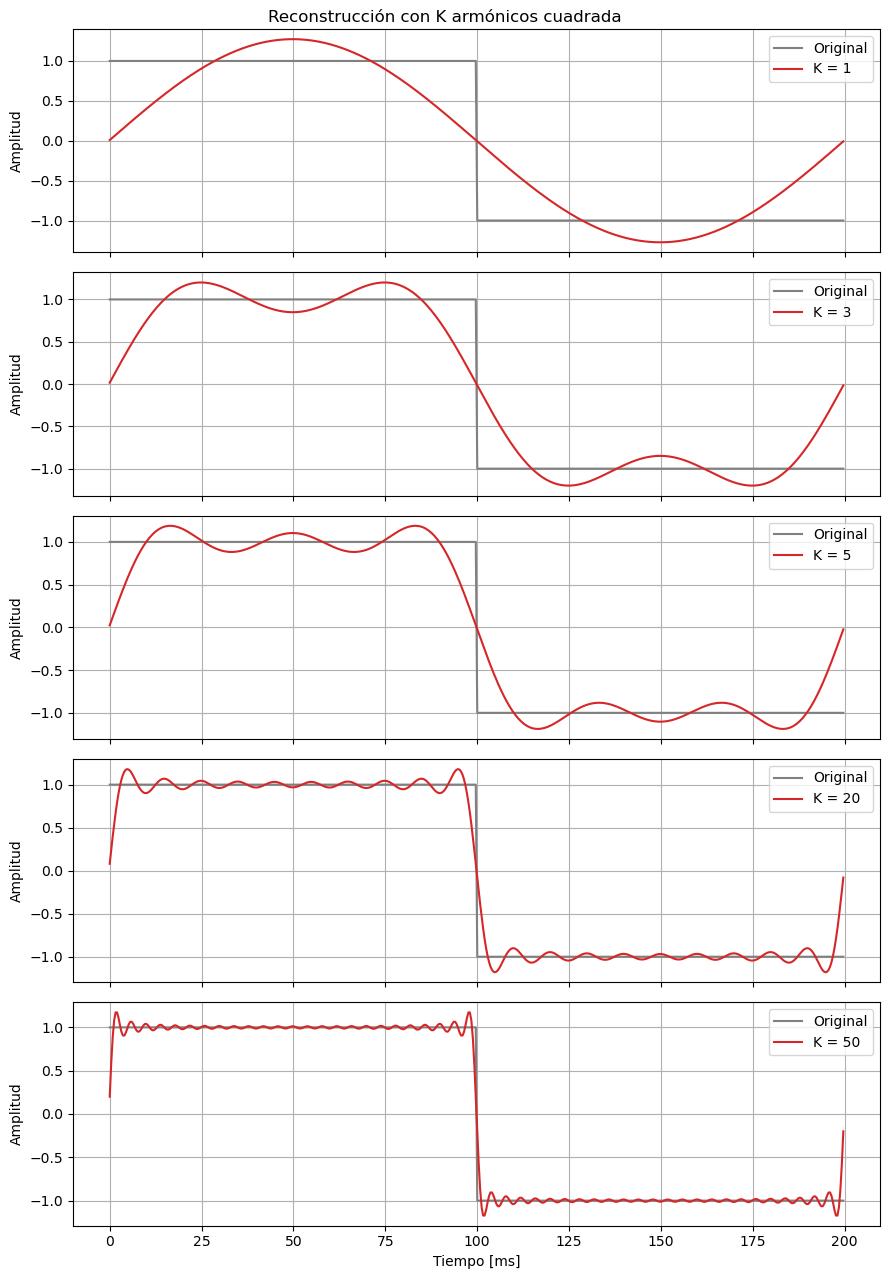

triangular | K =  1 | máximo de la reconstrucción = 0.8106
triangular | K =  3 | máximo de la reconstrucción = 0.9007
triangular | K =  5 | máximo de la reconstrucción = 0.9331
triangular | K = 20 | máximo de la reconstrucción = 0.9799
triangular | K = 50 | máximo de la reconstrucción = 0.9922


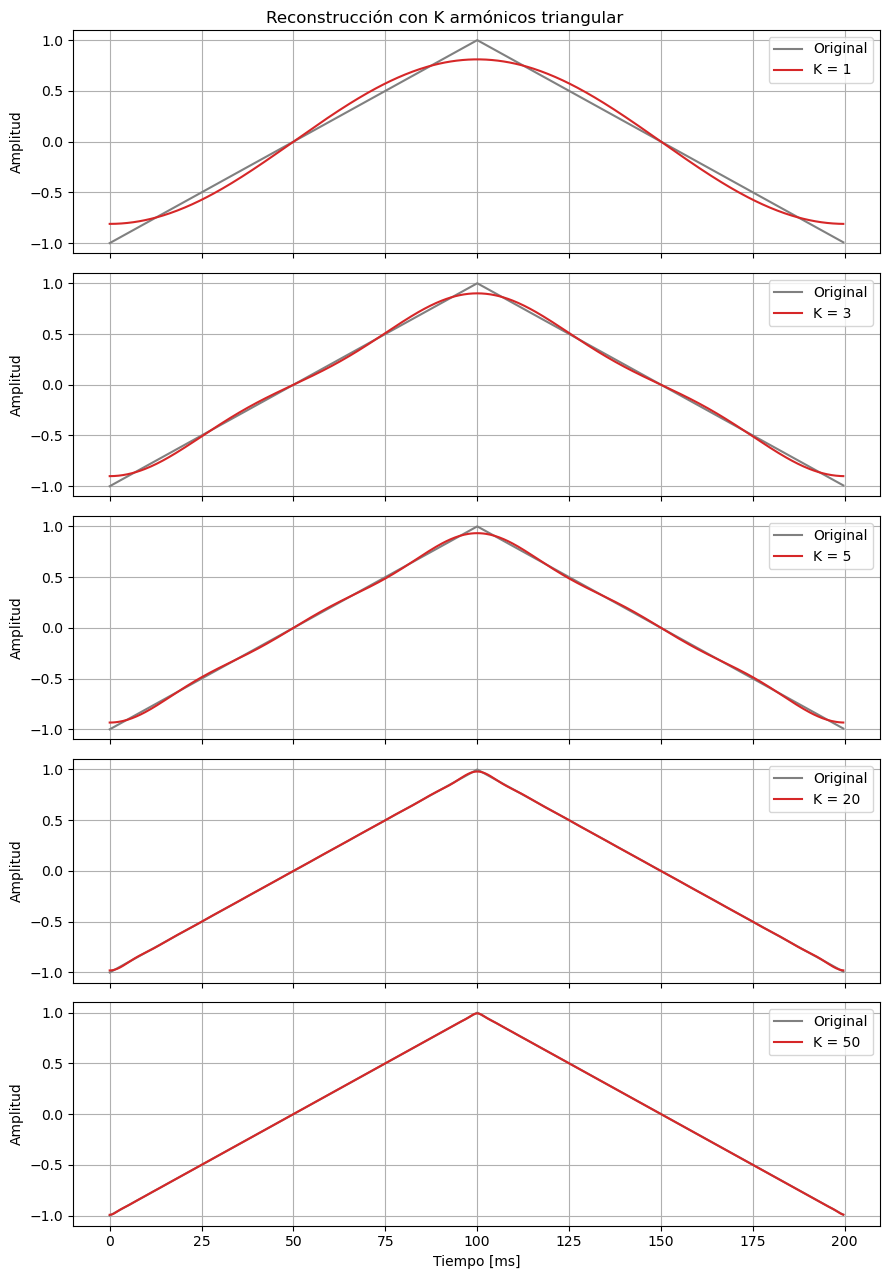

In [10]:
def graficar_reconstrucciones(t, x, k, c_k, Ks=(1, 3, 5, 20, 50), titulo=""):
    fig, axs = plt.subplots(len(Ks), 1, sharex=True, figsize=(9, 2.6 * len(Ks)))
    for ax, K in zip(axs, Ks):
        x_rec = reconstruir_senal(k, c_k, K)
        ax.plot(t * 1000, x, color='gray', label='Original')
        ax.plot(t * 1000, x_rec, color='tab:red', label=f'K = {K}')
        ax.set_ylabel('Amplitud')
        ax.legend(loc='upper right')
        ax.grid(True)
        print(f'{titulo} | K = {K:2d} | máximo de la reconstrucción = {x_rec.max():.4f}')
    axs[-1].set_xlabel('Tiempo [ms]')
    fig.suptitle(f'Reconstrucción con K armónicos {titulo}')
    plt.tight_layout()
    plt.show()

graficar_reconstrucciones(t, x_sq, k_sq, c_sq, titulo="cuadrada")
graficar_reconstrucciones(t, x_tri, k_tri, c_tri, titulo="triangular")

j) Consulte, analice y describa el fenómeno de Gibbs observado en las reconstrucciones de la señal
cuadrada.

### Fenómeno de Gibbs

**Qué es.** Cuando una señal periódica con discontinuidades (saltos bruscos),
como la onda cuadrada, se reconstruye con un número finito de armónicos, cerca
de cada salto aparecen oscilaciones y un sobrepico: la reconstrucción se pasa
del valor de la señal original. Al aumentar el número de armónicos, esas
oscilaciones se hacen más angostas y se pegan al salto, pero el sobrepico no
desaparece: se estabiliza en aproximadamente el 9 % del tamaño del salto [1].

**Qué observamos.** La cuadrada tiene amplitud 1, así que su salto va de -1 a +1.

| K (armónicos) | Máximo de la reconstrucción | Error RMS vs. original |
|---|---|---|
| 1  | 1.2732 | 0.4352 |
| 3  | 1.2004 | 0.3152 |
| 5  | 1.1884 | 0.2587 |
| 20 | 1.1803 | 0.1419 |
| 50 | 1.1724 | 0.0885 |

Con K = 1 la reconstrucción es una sinusoide con pico de 1.273. Desde K = 3 el
máximo ya no está en el centro de la parte plana, sino en las "orejas" junto al
salto. Su valor casi deja de bajar y se queda cerca de 1.18, es decir, unos 0.18
por encima de 1, en línea con el valor teórico de 1.179 [1]. Mientras tanto, el
error RMS sigue bajando de 0.435 a 0.089.

**Por qué ocurre.** Cada armónico es una sinusoide, una función continua y
suave. Una suma finita de funciones continuas es continua, así que no puede
saltar de -1 a +1 de forma instantánea: hace una transición rápida y, al
hacerla, se pasa. Más armónicos vuelven la transición más abrupta, pero el
exceso relativo se mantiene. Por eso el error promedio (RMS) tiende a cero
mientras que el error máximo junto al salto no.

**Comparación con la triangular.** La triangular es continua (no tiene saltos)
y sus coeficientes decaen como 1/k², más rápido que el 1/k de la cuadrada. Su
reconstrucción se acerca a la original por debajo (máximo 0.811 con K = 1 y
0.992 con K = 50), sin sobrepasarla, y no presenta Gibbs. Esto es relevante en
el ECG: el complejo QRS es una pendiente abrupta que depende de armónicos
altos, y al eliminarlos se pierde esa pendiente.

**Referencias**
[1] MIT OpenCourseWare, «Gibbs' Phenomenon», 18.03SC Differential Equations,
    otoño 2011. [En línea]. Disponible en: https://www.ocw.mit.edu/courses/18-03sc-differential-equations-fall-2011/05cce833730ffd3c39f420a41ad82fd6_MIT18_03SCF11_s22_7text.pdf
    [Consultado: fecha].

k) Cargue una señal ECG sin ruido y su composición espectral. Consulte y describa brevemente los
componentes de frecuencia principales asociados a las ondas P, al complejo QRS y a la onda T.

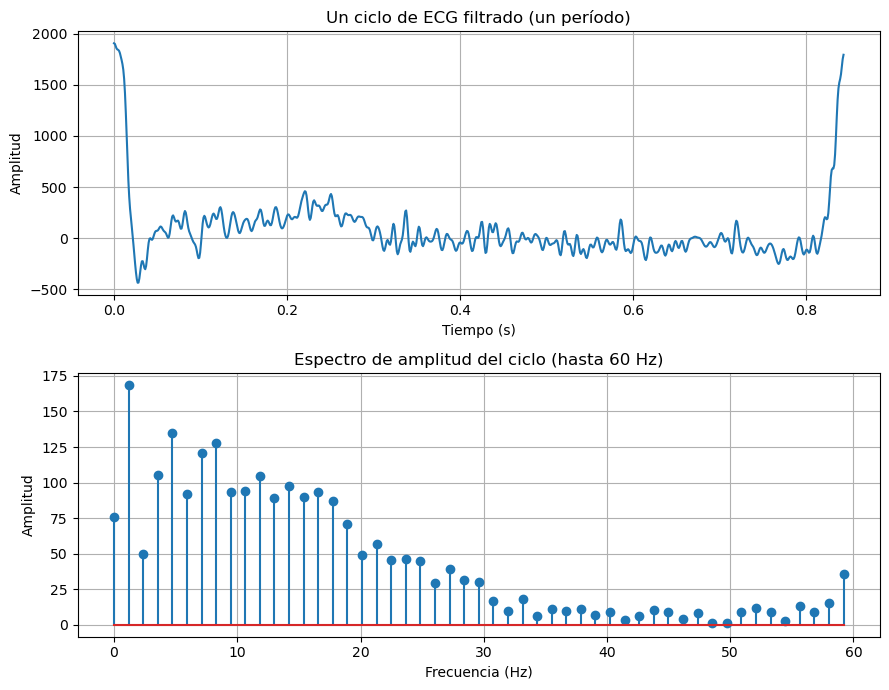

In [12]:
import scipy.io as sio
from scipy.signal import find_peaks

data = sio.loadmat("signals.mat")
fs = int(data["Fs"][0,0])
ecg_sin_filtrar = data["ECG_asRecording"].flatten()
ecg_filtrada = data["ECG_filtered"].flatten()

# Un ciclo de la señal filtrada (de un pico R al siguiente)
picos, _ = find_peaks(ecg_sin_filtrar, height=5500, distance=fs*0.5)
ciclo = ecg_filtrada[picos[0]:picos[1]]
N = len(ciclo)
T0 = N / fs
f0 = 1 / T0
t_ciclo = np.arange(N) / fs

# Coeficientes de Fourier del ciclo 
k_ecg, c_ecg = coeficientes_fourier(ciclo)

# Espectro unilateral en Hz
pos = k_ecg >= 0
f_hz = k_ecg[pos] * f0
amp = np.where(k_ecg[pos] == 0, np.abs(c_ecg[pos]), 2 * np.abs(c_ecg[pos]))

fig, axs = plt.subplots(2, 1, figsize=(9, 7))
axs[0].plot(t_ciclo, ciclo)
axs[0].set_title("Un ciclo de ECG filtrado (un período)")
axs[0].set_xlabel("Tiempo (s)")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)

lim = f_hz <= 60
axs[1].stem(f_hz[lim], amp[lim])
axs[1].set_title("Espectro de amplitud del ciclo (hasta 60 Hz)")
axs[1].set_xlabel("Frecuencia (Hz)")
axs[1].set_ylabel("Amplitud")
axs[1].grid(True)

plt.tight_layout()
plt.show()



**Señal y método:** Se utilizó la señal ECG filtrada de la práctica anterior
(muestreada a 1024 Hz). Se extrajo un ciclo cardiaco completo, de un pico R al
siguiente (865 muestras, T₀ = 0.845 s), y se trató como un período de la señal,
con frecuencia fundamental f₀ = 1/T₀ ≈ 1.18 Hz (unos 71 latidos por minuto).
Sus coeficientes de Fourier se calcularon con la función del punto d, y el
armónico k se asoció a la frecuencia k·f₀ para graficar el espectro de amplitud
en Hz.

**Resultado:** En el espectro, el armónico fundamental es el de mayor amplitud
y la energía se concentra en los primeros armónicos, hasta aproximadamente
30 Hz; a partir de allí las amplitudes son pequeñas.

**Componentes de frecuencia de las ondas P, QRS y T:** Según la literatura, el
contenido de la onda T se ubica sobre todo entre 0 y 10 Hz, el de la onda P
entre 5 y 30 Hz y el del complejo QRS entre 8 y 50 Hz [2]. Esta diferencia se
relaciona con la velocidad de propagación de la activación eléctrica: en el
sistema de His-Purkinje es la más rápida (2–4 m/s) y forma el QRS veloz, en las
aurículas es más lenta (0.5–1 m/s) y forma la onda P, y la repolarización se
propaga muy despacio y forma la onda T, de deflexión lenta [2]. Por eso el QRS,
con su pendiente abrupta, aporta las frecuencias más altas, mientras que P y T
aportan las bajas. Lo observado en el espectro es coherente con estos rangos:
el contenido del ciclo está entre 0 y unos 50 Hz.

**Limitaciones:** El espectro corresponde al ciclo completo, por lo que no
permite asignar cada armónico a una onda en particular. Además, al repetir un
solo ciclo como período queda una pequeña discontinuidad en el empalme, y la
señal utilizada conserva algo de ruido residual. Los límites de cada banda
varían entre fuentes, por lo que deben tomarse como aproximados.

### Referencias

[1] MIT OpenCourseWare, «Gibbs' Phenomenon», 18.03SC Differential Equations,
otoño 2011. [En línea]. Disponible en:
https://www.ocw.mit.edu/courses/18-03sc-differential-equations-fall-2011/05cce833730ffd3c39f420a41ad82fd6_MIT18_03SCF11_s22_7text.pdf
[Consultado: fecha].

[2] L. G. Tereshchenko and M. E. Josephson, "Frequency content and
characteristics of ventricular conduction," *J. Electrocardiol.*, vol. 48,
no. 6, pp. 933–937, 2015, doi: 10.1016/j.jelectrocard.2015.08.034.